In [30]:
# ── Configuration / Global Constants ───────────────────────────────────────
from pathlib import Path
import torch

# MODEL CONFIGURATION
MODEL_TYPE = "yolov8n.pt"  # Nano model for speed
# MODEL_TYPE = "yolov8s.pt"  # Small model for better accuracy
# MODEL_TYPE = "yolov8m.pt"  # Medium model
# MODEL_TYPE = "yolov8l.pt"  # Large model

# TRAINING HYPERPARAMETERS
IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 50 # Default from original notebook
PATIENCE = 10 # Default from original notebook
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0005
TEST_SIZE = 0.30
VAL_SIZE = 0.33
RANDOM_STATE = 42

# PATHS
RAW_DATA_PATH  = Path("/content/raw_data")
DATASET_PATH   = Path("/content/dataset")
RUNS_PATH = Path("/content/runs")
DRIVE_MODEL_DIR = Path("/content/drive/MyDrive/RDD2022_YOLO_Models")
QUARANTINE_PATH = Path("/content/quarantine")

# CLASS DEFINITIONS
CLASS_NAMES = [
    "longitudinal_crack",
    "transverse_crack",
    "alligator_crack",
    "pothole"
]
NUM_CLASSES = len(CLASS_NAMES)

TARGET_CLASS_MAP = {
    "D00": 0, # longitudinal crack
    "D10": 1, # transverse crack
    "D20": 2, # alligator crack
    "D40": 3  # pothole
}

# DEVICE
DEVICE = "0" if torch.cuda.is_available() else "cpu"

In [31]:
!pip install -q imagehash opencv-python-headless tqdm kaggle

In [32]:
!pip install -q ultralytics

In [33]:
# ── Environment Setup ──────────────────────────────────────────────────────
import os
import json
import logging
from pathlib import Path
import sys

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', stream=sys.stdout, force=True)

os.environ['KAGGLE_USERNAME'] = "paranietharan29"
os.environ['KAGGLE_KEY']      = "KGAT_21968fa3538f832e53f6adc53b096497"

# Ensure global paths are created
for p in [RAW_DATA_PATH, DATASET_PATH, QUARANTINE_PATH]:
    p.mkdir(parents=True, exist_ok=True)

logging.info("Environment setup complete.")

INFO: Environment setup complete.


In [34]:
# ── Imports ────────────────────────────────────────────────────────────────
import zipfile
import shutil
import numpy as np
import imagehash
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split

In [35]:
# ── Download Dataset ───────────────────────────────────────────────────────
def download_dataset():
    logging.info("entering into download dataset")
    zip_path = RAW_DATA_PATH / "rdd-2022.zip"
    existing_folders = [p for p in RAW_DATA_PATH.iterdir() if p.is_dir()]
    if existing_folders:
        logging.info(f"Dataset already extracted ({len(existing_folders)} folders found)")
        # delete the fodler
        for folder in existing_folders:
            logging.info(f"Deleting folder: {folder}")
            shutil.rmtree(folder)

    logging.info("Downloading RDD-2022 dataset (~9.9 GB)...")
    os.system(f"kaggle datasets download -d aliabdelmenam/rdd-2022 -p {RAW_DATA_PATH}")

    if zip_path.exists():
        logging.info("Extracting zip...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(RAW_DATA_PATH)
        zip_path.unlink()  # delete zip after extraction to free space
        logging.info("Extraction complete. Zip deleted to save space.")
    else:
        logging.error("Download failed — zip not found. Check your Kaggle credentials.")

In [36]:
# ── VOC → YOLO Conversion ──────────────────────────────────────────────────
def convert_voc_to_yolo(xml_file, target_class_map=None):
    """Parse a PascalVOC XML and return YOLO-format label strings.

    FIX: uses explicit named variables for coordinates instead of a
    positional tuple (b[0]..b[3]) which was error-prone and confusing.
    The math is identical but now self-documenting and safe.
    """
    # Use the global TARGET_CLASS_MAP if not provided
    if target_class_map is None:
        target_class_map = TARGET_CLASS_MAP

    try:
        tree = ET.parse(xml_file)
    except ET.ParseError as e:
        logging.warning(f"Malformed XML skipped: {xml_file} — {e}")
        return []

    root = tree.getroot()
    size = root.find('size')
    if size is None:
        return []

    w = int(size.find('width').text)
    h = int(size.find('height').text)
    if w == 0 or h == 0:
        return []

    yolo_labels = []
    for obj in root.iter('object'):
        cls_name = obj.find('name').text
        if cls_name not in target_class_map:
            logging.warning(f"Skipping unknown class '{cls_name}' in {xml_file}")
            continue

        cls_id = target_class_map[cls_name]
        xmlbox = obj.find('bndbox')

        # FIX: explicit names — no more confusing b[0]..b[3] indexing
        xmin = float(xmlbox.find('xmin').text)
        xmax = float(xmlbox.find('xmax').text)
        ymin = float(xmlbox.find('ymin').text)
        ymax = float(xmlbox.find('ymax').text)

        # Add invalid bbox rejection: xmax <= xmin or ymax <= ymin
        if xmax <= xmin or ymax <= ymin:
            logging.warning(f"Skipping invalid bounding box in {xml_file} for class {cls_name}: xmin={xmin}, xmax={xmax}, ymin={ymin}, ymax={ymax}")
            continue

        # YOLO format: x_center y_center width height (all normalised 0–1)
        x_center = (xmin + xmax) / (2.0 * w)
        y_center = (ymin + ymax) / (2.0 * h)
        bbox_w   = (xmax - xmin) / w
        bbox_h   = (ymax - ymin) / h

        # Clamp to [0, 1] to guard against annotation errors
        x_center = max(0.0, min(1.0, x_center))
        y_center = max(0.0, min(1.0, y_center))
        bbox_w   = max(0.0, min(1.0, bbox_w))
        bbox_h   = max(0.0, min(1.0, bbox_h))

        yolo_labels.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {bbox_w:.6f} {bbox_h:.6f}")

    return yolo_labels

In [37]:
import os
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from collections import defaultdict
import logging
import shutil

def clean_and_process():
    """
    Scans raw data for images and labels, performs integrity checks, and prepares samples.
    This function is refactored to support multi-class detection and handles both
    YOLO (.txt) and Pascal VOC (.xml) label formats based on `TARGET_CLASS_MAP`.
    """
    valid_samples = []
    stats = defaultdict(int)
    class_counter = defaultdict(int)
    image_class_frequency = defaultdict(set) # Use a set to count unique images per class

    all_image_paths = []
    # Recursively find all JPG images under RAW_DATA_PATH
    for root, dirs, files in os.walk(RAW_DATA_PATH):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg')):
                all_image_paths.append(Path(root) / file)

    logging.info(f"Found {len(all_image_paths)} images across all identified subdirectories under {RAW_DATA_PATH}.")

    if not all_image_paths:
        logging.error(f"No JPG/JPEG images found under {RAW_DATA_PATH}. Check your dataset download and extraction.")
        return []

    for img_path in tqdm(all_image_paths, desc="Processing images and labels"):
        # Integrity check
        try:
            with Image.open(img_path) as im:
                im.verify()
        except (UnidentifiedImageError, OSError, Exception) as e:
            stats['integrity_fail'] += 1
            logging.warning(f"Image integrity failed for {img_path}: {e}. Moving to quarantine.")
            QUARANTINE_PATH.mkdir(exist_ok=True)
            shutil.move(img_path, QUARANTINE_PATH / img_path.name)
            continue

        processed_labels = []
        current_image_classes = set()

        # Logic to find the corresponding XML or YOLO TXT label
        # 1. Try to find XML in a sibling 'annotations' directory (typical for RDD2022 raw data)
        #    e.g., /content/raw_data/Japan/images/img.jpg -> /content/raw_data/Japan/annotations/img.xml
        parent_dir = img_path.parent # This is 'images'
        grandparent_dir = parent_dir.parent # This is 'Japan' or 'RDD_SPLIT/train' etc.

        xml_label_path = grandparent_dir / 'annotations' / img_path.with_suffix(".xml").name
        yolo_label_path = grandparent_dir / 'labels' / img_path.with_suffix(".txt").name

        if xml_label_path.exists():
            processed_labels = convert_voc_to_yolo(xml_label_path, TARGET_CLASS_MAP)
            if not processed_labels:
                stats['empty_label'] += 1
                logging.warning(f"XML file {xml_label_path} processed but yielded no valid labels.")
                continue
            for label_line in processed_labels:
                cls_id = int(label_line.split()[0])
                class_counter[cls_id] += 1
                current_image_classes.add(cls_id)

        elif yolo_label_path.exists():
            # This path is less preferred as these TXT files might be single-class or derived.
            # But we include it for robustness in case some splits only have TXT.
            lines = [l.strip() for l in yolo_label_path.read_text().splitlines() if l.strip()]
            if not lines:
                stats['empty_label'] += 1
                logging.warning(f"YOLO TXT file {yolo_label_path} is empty.")
                continue

            for line in lines:
                parts = line.split()
                if len(parts) == 5:
                    try:
                        cls_id = int(parts[0])
                        if 0 <= cls_id < NUM_CLASSES: # Validate class ID range
                            processed_labels.append(line)
                            class_counter[cls_id] += 1
                            current_image_classes.add(cls_id)
                        else:
                            stats['invalid_class'] += 1
                            logging.warning(f"Invalid class ID {cls_id} in {yolo_label_path}. Skipping label: {line}")
                    except ValueError:
                        stats['invalid_format'] += 1
                        logging.warning(f"Invalid YOLO label format in {yolo_label_path}. Skipping label: {line}")
                else:
                    stats['invalid_format'] += 1
                    logging.warning(f"Invalid YOLO label format (incorrect number of parts) in {yolo_label_path}. Skipping label: {line}")
        else:
            stats['no_label'] += 1
            # logging.debug(f"No XML or YOLO TXT label found for {img_path}") # Can be too verbose
            continue

        if processed_labels:
            valid_samples.append({'img': img_path, 'labels': processed_labels})
            for cls_id in current_image_classes:
                image_class_frequency[cls_id].add(img_path) # Add image path to the set for each class it contains
        else:
            stats['empty_label_after_processing'] += 1 # If labels were invalid or skipped

    logging.info(f"Cleaning and processing complete. Found {len(valid_samples)} valid samples.")
    logging.info(f"Statistics: {dict(stats)}")

    # Class distribution logging
    logging.info("Class Distribution (Object Instances):")
    for cls_id in sorted(class_counter.keys()):
        logging.info(f"  Class {cls_id} ({CLASS_NAMES[cls_id]}): {class_counter[cls_id]} instances")
    logging.info("Class Distribution (Image Frequency):")
    for cls_id in range(NUM_CLASSES): # Iterate through all possible classes
        logging.info(f"  Class {cls_id} ({CLASS_NAMES[cls_id]}): {len(image_class_frequency[cls_id])} images")

    return valid_samples

In [38]:
# ── Dataset Splitting & YOLO Config ───────────────────────────────────────
def finalize_dataset(samples):
    if not samples:
        logging.error("Cannot finalize dataset: samples list is empty!")
        return

    # Use global TEST_SIZE, VAL_SIZE, and RANDOM_STATE
    train, temp = train_test_split(samples, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    val,   test = train_test_split(temp,    test_size=VAL_SIZE, random_state=RANDOM_STATE)

    logging.info(f"Split sizes — train: {len(train)}, val: {len(val)}, test: {len(test)}")

    splits = {'train': train, 'val': val, 'test': test}
    for split_name, data in splits.items():
        img_dir   = DATASET_PATH / split_name / 'images'
        label_dir = DATASET_PATH / split_name / 'labels'
        img_dir.mkdir(parents=True, exist_ok=True)
        label_dir.mkdir(parents=True, exist_ok=True)

        for item in data:
            # Defensive: ensure destination filename doesn't already exist or handle collision
            dest_img_path = img_dir / item['img'].name
            if dest_img_path.exists():
                logging.warning(f"Duplicate image filename detected: {dest_img_path.name}. Overwriting.")
            shutil.copy(item['img'], dest_img_path)

            label_path = label_dir / f"{item['img'].stem}.txt"
            with open(label_path, 'w') as f:
                f.write("\n".join(item['labels']))

    # Generate proper data.yaml for multi-class
    names_str = "\n".join([f"  - {name}" for name in CLASS_NAMES])
    yaml_content = (
        f"path: {DATASET_PATH}\n"
        f"train: train/images\n"
        f"val:   val/images\n"
        f"test:  test/images\n"
        f"nc: {NUM_CLASSES}\n"
        f"names:\n{names_str}\n"
    )
    yaml_path = DATASET_PATH / 'data.yaml'
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    logging.info(f"Dataset finalised. YAML written to {yaml_path}")

In [39]:
download_dataset()

INFO: entering into download dataset
INFO: Dataset already extracted (1 folders found)
INFO: Deleting folder: /content/raw_data/RDD_SPLIT
INFO: Downloading RDD-2022 dataset (~9.9 GB)...
INFO: Extracting zip...
INFO: Extraction complete. Zip deleted to save space.


In [40]:
valid_data = clean_and_process()

INFO: Found 38385 images across all identified subdirectories under /content/raw_data.


Processing images and labels:   0%|          | 0/38385 [00:00<?, ?it/s]

Processing images and labels:   0%|          | 16/38385 [00:00<04:04, 157.21it/s]

Processing images and labels:   0%|          | 36/38385 [00:00<03:30, 182.10it/s]

Processing images and labels:   0%|          | 58/38385 [00:00<03:14, 197.39it/s]

...

Processing images and labels:  99%|█████████▉| 38171/38385 [01:49<00:00, 1022.26it/s]

Processing images and labels: 100%|█████████▉| 38275/38385 [01:49<00:00, 961.53it/s] 

Processing images and labels: 100%|█████████▉| 38373/38385 [01:50<00:00, 898.56it/s]

Processing images and labels: 100%|██████████| 38385/38385 [01:50<00:00, 348.75it/s]

INFO: Cleaning and processing complete. Found 25430 valid samples.
INFO: Statistics: {'empty_label': 11724, 'invalid_class': 6544, 'empty_label_after_processing': 1231}
INFO: Class Distribution (Object Instances):
INFO:   Class 0 (longitudinal_crack): 26016 instances
INFO:   Class 1 (transverse_crack): 11830 instances
INFO:   Class 2 (alligator_crack): 10617 instances
INFO:   Class 3 (pothole): 10705 instances
INFO: Class Distribution (Image Frequency):
INFO:   Class 0 (longitudinal_crack): 13548 images
INFO:   Class 1 (transverse_crack): 7709 images
INFO:   Class 2 (alligator_crack): 8412 images
INFO:   Class 3 (pothole): 7440 images


In [41]:
# ── Finalize Dataset
finalize_dataset(valid_data)

Streaming output truncated to the last 5000 lines.
INFO: Dataset finalised. YAML written to /content/dataset/data.yaml


/tmp/ipykernel_7316/1525917135.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_instances, ax=axes[0], palette='viridis')
/tmp/ipykernel_7316/1525917135.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_images, ax=axes[1], palette='plasma')


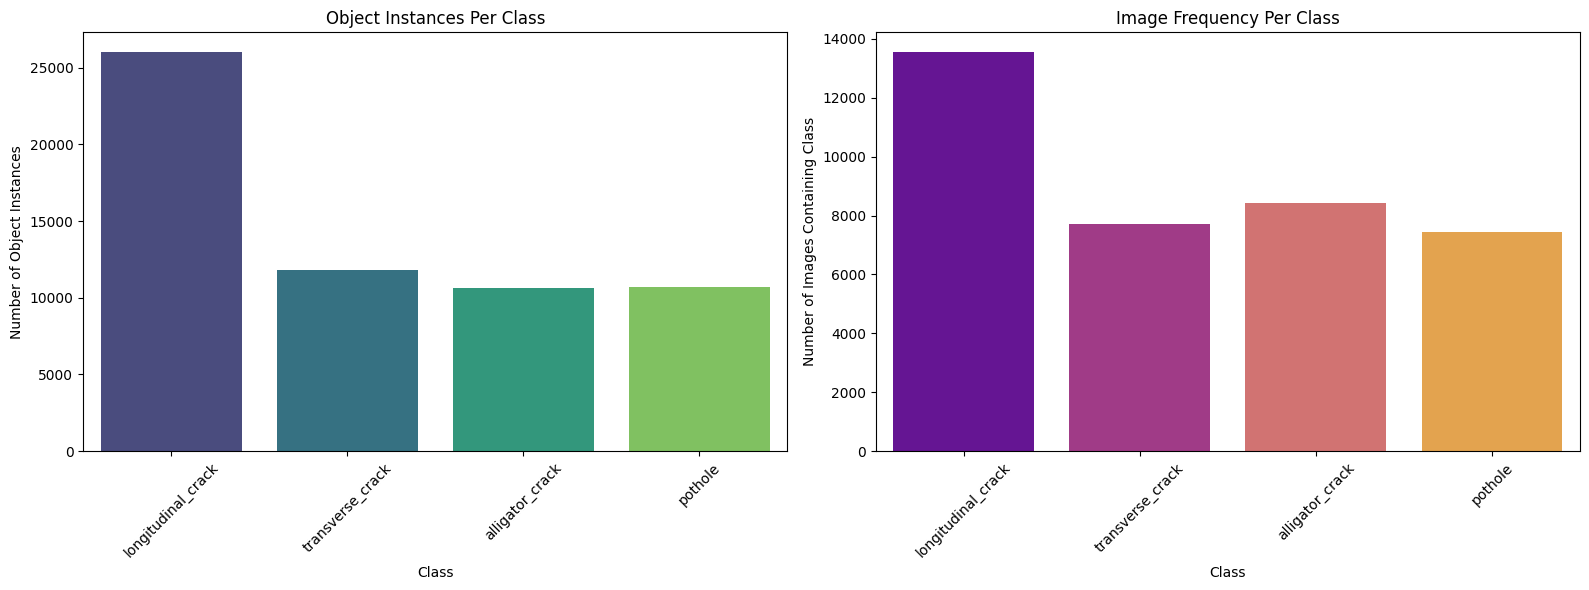

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict
import logging

# Recalculate class distribution from valid_data
class_counter = defaultdict(int)
image_class_frequency = defaultdict(set) # Use a set to count unique images per class

for sample in valid_data:
    img_path = sample['img']
    for label_line in sample['labels']:
        try:
            cls_id = int(label_line.split()[0])
            class_counter[cls_id] += 1
            image_class_frequency[cls_id].add(img_path) # Add image to set for this class
        except (ValueError, IndexError):
            logging.warning(f"Could not parse label line: {label_line} in {img_path}")

# Convert image_class_frequency sets to counts, ensuring all NUM_CLASSES are present
image_frequency_counts = {cls_id: len(img_paths) for cls_id, img_paths in image_class_frequency.items()}

# Prepare data for plotting
plot_data_instances = []
plot_data_images = []

# Iterate through class IDs from 0 to NUM_CLASSES-1
for cls_id in range(NUM_CLASSES):
    class_name = CLASS_NAMES[cls_id] # Access class name by index
    # Use .get() with a default value of 0 to handle cases where a class might have no instances/images
    plot_data_instances.append({'Class': class_name, 'Count': class_counter.get(cls_id, 0)})
    plot_data_images.append({'Class': class_name, 'Count': image_frequency_counts.get(cls_id, 0)})

df_instances = pd.DataFrame(plot_data_instances)
df_images = pd.DataFrame(plot_data_images)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Class', y='Count', data=df_instances, ax=axes[0], palette='viridis')
axes[0].set_title('Object Instances Per Class')
axes[0].set_ylabel('Number of Object Instances')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Class', y='Count', data=df_images, ax=axes[1], palette='plasma')
axes[1].set_title('Image Frequency Per Class')
axes[1].set_ylabel('Number of Images Containing Class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [43]:
import torch
from ultralytics import YOLO
from pathlib import Path

# Initialize model
model = YOLO(MODEL_TYPE)

# Start training with full parameterization
results = model.train(
    data=str(DATASET_PATH / "data.yaml"),
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device="0" if torch.cuda.is_available() else "cpu",
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    augment=True,
    cache=False,
    workers=2,
    project="/content/runs",
    name="rdd2022_yolov8_optimized",
    exist_ok=True
)

# Capture best weights path
best_weights = Path(results.save_dir) / 'weights' / 'best.pt'
print(f"\n✅ Training complete. Best weights: {best_weights}")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rdd2022_yolov8_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

KeyboardInterrupt: 

In [ ]:
# ── Validate on val set ───────────────────────────────────────────────────
metrics = model.val()
print("mAP50:    ", metrics.box.map50)
print("mAP50-95: ", metrics.box.map)

In [12]:
from google.colab import drive
import shutil
from pathlib import Path

def save_model_to_drive(model_source_path, drive_folder_name="RDD2022_YOLO_Models"):
    logging.info("Mounting Google Drive...")
    drive.mount('/content/drive')

    drive_dest_dir = Path(f"/content/drive/MyDrive/{drive_folder_name}")
    drive_dest_dir.mkdir(parents=True, exist_ok=True)

    model_filename = Path(model_source_path).name
    dest_path = drive_dest_dir / model_filename

    if Path(model_source_path).exists():
        logging.info(f"Copying model from {model_source_path} to {dest_path}")
        shutil.copy(model_source_path, dest_path)
        logging.info(f"Model saved to Google Drive: {dest_path}")
    else:
        logging.error(f"Model file not found at {model_source_path}. Please ensure training completed successfully and the path is correct.")


In [ ]:
save_model_to_drive(best_weights)

In [16]:
from google.colab import drive
from ultralytics import YOLO
from pathlib import Path
import glob
import logging

logging.info("Mounting Google Drive to load the model...")
drive.mount('/content/drive')

# Define the path to the model saved on Google Drive
# This path should match where save_model_to_drive saved the 'best.pt' file.
drive_model_path = Path('/content/drive/MyDrive/RDD2022_YOLO_Models/best.pt')

if drive_model_path.exists():
    logging.info(f"Loading model from Google Drive: {drive_model_path}")
    loaded_model = YOLO(drive_model_path)

    # Get a few test images from the previously prepared DATASET_PATH
    test_images = glob.glob(str(DATASET_PATH / "test/images/*.jpg"))
    if not test_images:
        logging.error("No test images found in the dataset's test split. Please ensure the dataset was finalized correctly.")
    else:
        # Take up to 5 test images for demonstration
        sample_test_images = test_images[:5]
        logging.info(f"Running inference on {len(sample_test_images)} sample test images...")
        # Use the loaded_model to make predictions
        # Setting save=True will save annotated images to /content/runs/predict_from_drive/
        results_from_drive = loaded_model.predict(sample_test_images, conf=0.25, save=True, project="/content/runs", name="predict_from_drive")
        print(f"\nPredictions saved to /content/runs/predict_from_drive/ for the following images:")
        for img_path in sample_test_images:
            print(f"  - {Path(img_path).name}")

else:
    logging.error(f"Model not found at {drive_model_path}. Please ensure the model was saved to Google Drive correctly.")

INFO: Mounting Google Drive to load the model...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Loading model from Google Drive: /content/drive/MyDrive/RDD2022_YOLO_Models/best.pt
INFO: Running inference on 5 sample test images...

0: 640x640 4 road_damages, 882.7ms
1: 640x640 1 road_damage, 882.7ms
2: 640x640 (no detections), 882.7ms
3: 640x640 (no detections), 882.7ms
4: 640x640 (no detections), 882.7ms
Speed: 51.8ms preprocess, 882.7ms inference, 32.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/predict_from_drive

Predictions saved to /content/runs/predict_from_drive/ for the following images:
  - China_MotorBike_000376.jpg
  - Norway_008147.jpg
  - Norway_006514.jpg
  - United_States_003096.jpg
  - India_003083.jpg


In [21]:
from ultralytics import YOLO
from pathlib import Path
import logging
from google.colab import drive

logging.info("Mounting Google Drive to load the model for accuracy evaluation...")
drive.mount('/content/drive')

# Define the path to the model saved on Google Drive using the global constant
drive_model_path = DRIVE_MODEL_DIR / 'best.pt'

if drive_model_path.exists():
    logging.info(f"Loading model from Google Drive: {drive_model_path}")
    loaded_model_for_accuracy = YOLO(str(drive_model_path))

    # Run validation on the test set
    logging.info("Calculating accuracy on the test set...")
    metrics = loaded_model_for_accuracy.val(
        data=str(DATASET_PATH / "data.yaml"),
        split="test",
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        # save_json=True, # Saves validation results to a json file
        save_hybrid=True, # Saves pred to txt and labels to txt
        plots=True # Saves plots like confusion matrix, curves, etc.
    )

    print("\n--- Model Accuracy Metrics on Test Set ---")
    # Overall Metrics
    print("OVERALL:")
    print(f"  Precision: {metrics.box.p.item():.4f}")
    print(f"  Recall:    {metrics.box.r.item():.4f}")
    print(f"  mAP50:     {metrics.box.map50.item():.4f}")
    print(f"  mAP50-95:  {metrics.box.map.item():.4f}")

    # Per-Class Metrics
    print("\nPER CLASS:")
    # metrics.results_dict contains per-class metrics in the format 'metrics/precision(B)/class0'
    for i, class_name in enumerate(CLASS_NAMES):
        p_key = f"metrics/precision(B)/class{i}"
        r_key = f"metrics/recall(B)/class{i}"
        map50_key = f"metrics/mAP50(B)/class{i}"
        map_key = f"metrics/mAP50-95(B)/class{i}"

        precision = metrics.results_dict.get(p_key, 0.0) # Default to 0.0 if not found
        recall = metrics.results_dict.get(r_key, 0.0)
        map50 = metrics.results_dict.get(map50_key, 0.0)
        map = metrics.results_dict.get(map_key, 0.0)

        print(f"  Class {i} ({class_name}):")
        print(f"    Precision: {precision:.4f}")
        print(f"    Recall:    {recall:.4f}")
        print(f"    mAP50:     {map50:.4f}")
        print(f"    mAP50-95:  {map:.4f}")

    # Confusion Matrix and other plots are saved automatically by plots=True
    run_dir = Path(metrics.save_dir)
    print(f"\nValidation results, including confusion matrix and plots, saved to: {run_dir}")

else:
    logging.error(f"Model not found at {drive_model_path}. Cannot evaluate accuracy.")

INFO: Mounting Google Drive to load the model for accuracy evaluation...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Loading model from Google Drive: /content/drive/MyDrive/RDD2022_YOLO_Models/best.pt
INFO: Calculating accuracy on the test set...
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1528.2±528.9 MB/s, size: 210.0 KB)
val: Scanning /content/dataset/test/labels.cache... 937 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 937/937 187.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 4.6s/it 4:30
                   all        937       1834      0.707        0.6      0.641      0.367
Speed: 6.7ms preprocess, 264.5ms inference, 0.0ms loss, 0.6ms pos